In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS = os.path.join(BASE_DIR, "data", "results", "anti", "anti.csv")

df = pd.read_csv(RESULTS)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [4]:
clean = df[df["is_timeout"] == False].copy()

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

sqrt_ref = (
    clean[clean["impl"] == "sqrt"]
    .groupby("dataset")
    .agg(
        cnt_nodes=("cnt_nodes", "first"),
        cnt_links=("cnt_links", "first"),
        cnt_dist=("cnt_distinguishable_suffixes",
                  lambda s: s[s >= 0].iloc[0]),
        avg_overlap=("avg_overlap", "mean")
    )
)

clean["cnt_nodes"] = clean["dataset"].map(sqrt_ref["cnt_nodes"])
clean["cnt_links"] = clean["dataset"].map(sqrt_ref["cnt_links"])
clean["cnt_distinguishable_suffixes"] = clean["dataset"].map(sqrt_ref["cnt_dist"])
clean["avg_overlap"] = clean["avg_overlap"].map(sqrt_ref["avg_overlap"])

clean

,dataset,status,impl,positive_set_size,negative_set_size,number_of_queries,build_time_ms,query_time_ms,memory_mib,total_output_len,cnt_symbols,cnt_nodes,cnt_links,cnt_distinguishable_suffixes,avg_overlap,is_timeout
0,anti_naive1,OK,naive,17.0,15.0,100000.0,0.181,1386.889,0.109772,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
1,anti_naive1,OK,precomp,17.0,15.0,100000.0,5.593,38.563,1.791016,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
2,anti_naive1,OK,sqrt,17.0,15.0,100000.0,4.912,33.024,1.779575,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
3,anti_naive1,OK,naive,17.0,15.0,100000.0,0.173,1459.062,0.109772,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
4,anti_naive1,OK,precomp,17.0,15.0,100000.0,6.739,35.426,1.791016,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
5,anti_naive1,OK,sqrt,17.0,15.0,100000.0,16.279,53.297,1.779575,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
6,anti_naive1,OK,naive,17.0,15.0,100000.0,0.180,1206.627,0.109772,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
7,anti_naive1,OK,precomp,17.0,15.0,100000.0,5.838,31.222,1.791016,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
8,anti_naive1,OK,sqrt,17.0,15.0,100000.0,6.103,25.277,1.779575,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False
9,anti_naive1,OK,naive,17.0,15.0,100000.0,0.183,1184.889,0.109772,100000.0,2902.0,4543.0,2934.0,597.0,NaN,False


In [5]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "mean"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first"),
            cnt_nodes=("cnt_nodes", "first"),
            cnt_links=("cnt_links", "first"),
            cnt_dist=("cnt_distinguishable_suffixes", "first"),
            avg_overlap=("avg_overlap", "first")
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)

summary["link_density"] = (
    summary["cnt_links"] / 
    summary["cnt_nodes"]
)

summary["dist_ratio"] = (
    summary["cnt_dist"] / 
    summary["cnt_links"]
)

summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,cnt_nodes,cnt_links,cnt_dist,avg_overlap,total_mean_ms,query_ms_per_query,num_traces,link_density,dist_ratio
0,anti_naive1,naive,0.1772,0.005933,1340.9414,136.388878,0.109772,17.0,15.0,100000.0,4543.0,2934.0,597.0,NaN,1341.1186,0.013409,32.0,0.645829,0.203476
1,anti_naive1,precomp,6.3966,0.794343,41.0200,15.590155,1.791016,17.0,15.0,100000.0,4543.0,2934.0,597.0,NaN,47.4166,0.000410,32.0,0.645829,0.203476
2,anti_naive1,sqrt,8.8814,4.430505,36.4408,10.587576,1.779575,17.0,15.0,100000.0,4543.0,2934.0,597.0,NaN,45.3222,0.000364,32.0,0.645829,0.203476
3,anti_naive2,naive,151.0074,55.881571,20692.2958,726.916929,72.088745,2.0,0.0,1000.0,NaN,NaN,NaN,NaN,20843.3032,20.692296,2.0,NaN,NaN
4,anti_naive2,precomp,5148.8452,178.682246,0.0878,0.059500,1065.933289,2.0,0.0,1000.0,NaN,NaN,NaN,NaN,5148.9330,0.000088,2.0,NaN,NaN
5,anti_naive3,naive,7.6710,3.532568,35496.3370,176.926683,4.219208,2.0,0.0,50000.0,150006.0,100004.0,0.0,NaN,35504.0080,0.709927,2.0,0.666667,0.000000
6,anti_naive3,precomp,233.0782,5.144945,2.4950,0.313055,59.069534,2.0,0.0,50000.0,150006.0,100004.0,0.0,NaN,235.5732,0.000050,2.0,0.666667,0.000000
7,anti_naive3,sqrt,265.2250,23.481881,2.7904,1.167678,59.069538,2.0,0.0,50000.0,150006.0,100004.0,0.0,NaN,268.0154,0.000056,2.0,0.666667,0.000000
8,anti_naive4,precomp,671.9668,79.001576,4.4562,1.782001,152.220772,102.0,100.0,100000.0,377191.0,240204.0,25150.0,NaN,676.4230,0.000045,202.0,0.636823,0.104703
9,anti_naive4,sqrt,721.8308,49.759847,4.1200,0.238341,151.660183,102.0,100.0,100000.0,377191.0,240204.0,25150.0,NaN,725.9508,0.000041,202.0,0.636823,0.104703


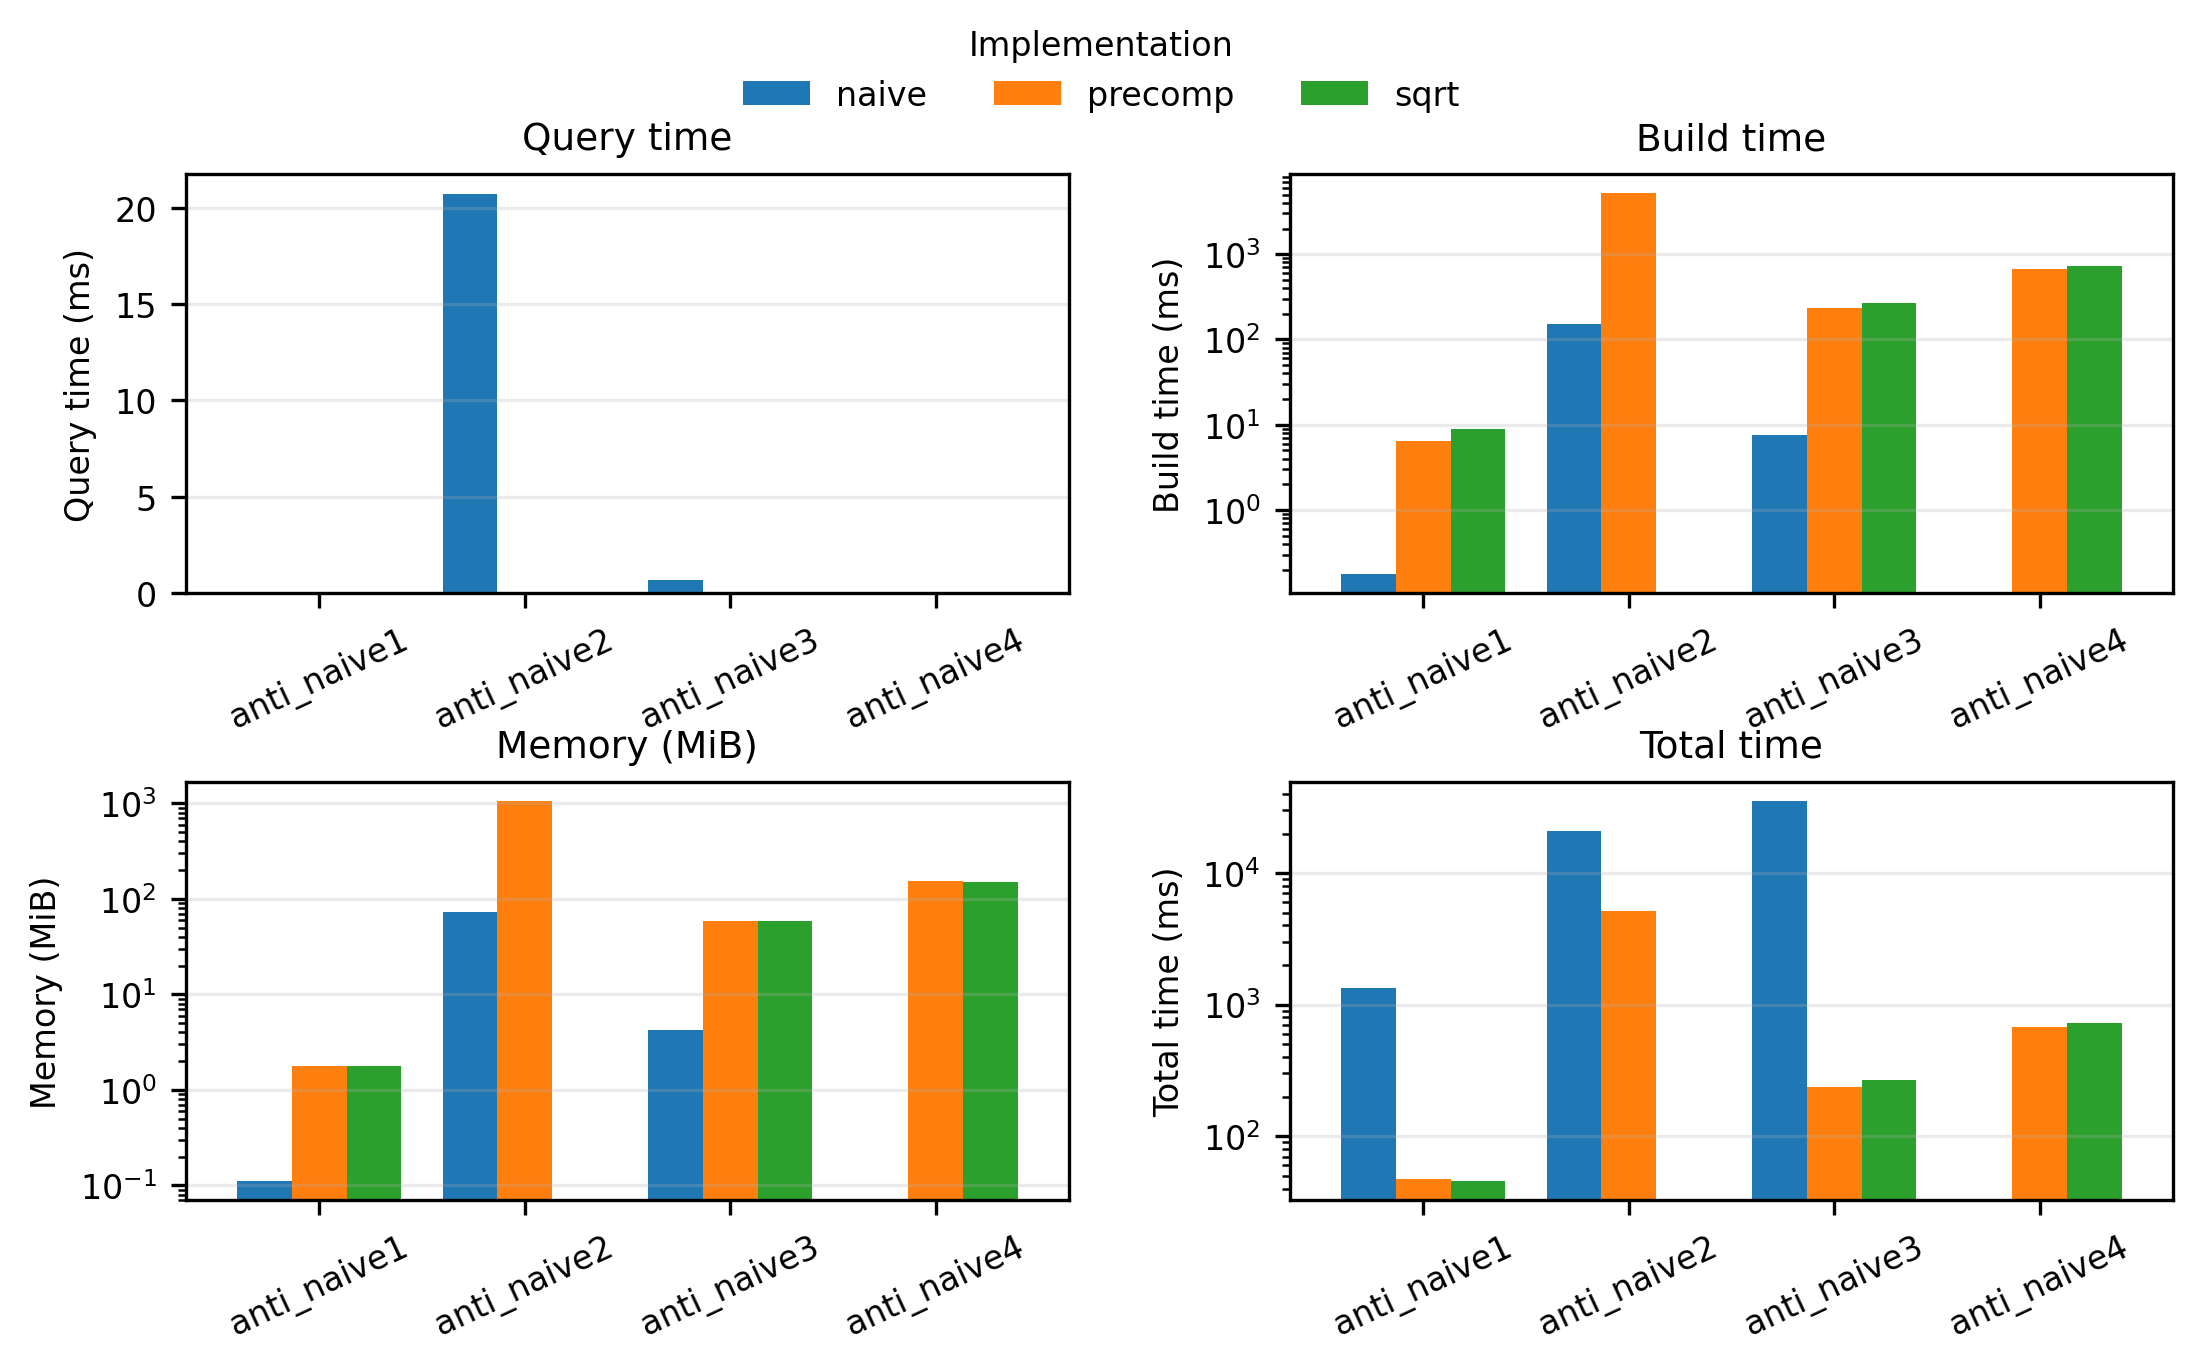

In [6]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.5), dpi=300)

metrics = [
    ("query_ms_per_query", "Query time (ms)", False),
    ("build_mean_ms", "Build time (ms)", True),
    ("memory_mib", "Memory (MiB)", True),
    ("total_mean_ms", "Total time (ms)", True),
]

for ax, (metric, ylabel, use_log) in zip(axes.flat, metrics):
    pivot = summary.pivot(
        index="dataset",
        columns="impl",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(ylabel.replace(" (ms)", "") if "ms" in ylabel else ylabel)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if use_log:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Implementation",
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
)

for ax in axes.flat:
    ax.legend().remove()

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.88,
    wspace=0.25,
    hspace=0.45
)

plt.show()

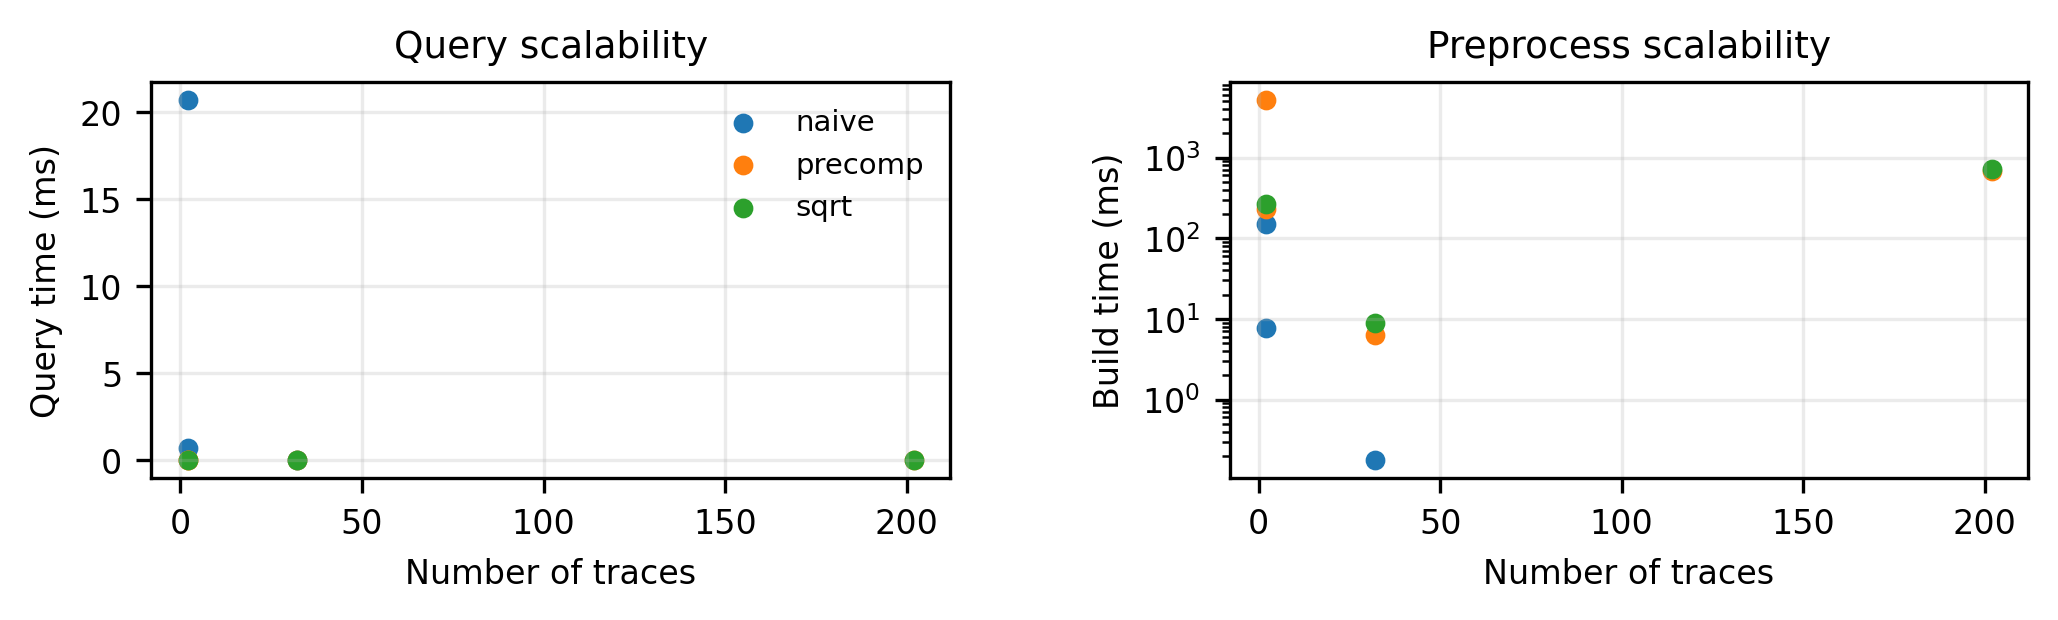

In [7]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.2), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    axes[0].scatter(
        sub["num_traces"],
        sub["query_ms_per_query"],
        s=14,
        label=impl
    )

axes[0].set_title("Query scalability")
axes[0].set_xlabel("Number of traces")
axes[0].set_ylabel("Query time (ms)")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False, fontsize=7, loc="best")

for impl in impls:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    axes[1].scatter(
        sub["num_traces"],
        sub["build_mean_ms"],
        s=14
    )

axes[1].set_title("Preprocess scalability")
axes[1].set_xlabel("Number of traces")
axes[1].set_ylabel("Build time (ms)")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.25)

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.25,
    top=0.85,
    wspace=0.35
)

plt.show()

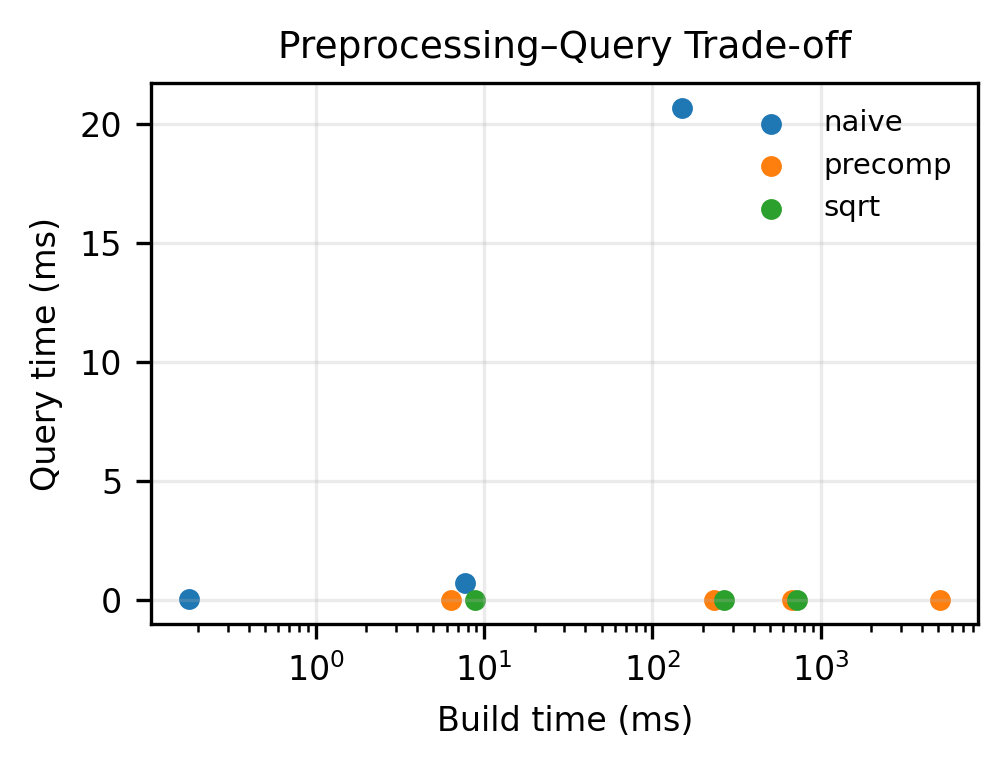

In [8]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl]
    ax.scatter(
        sub["build_mean_ms"],
        sub["query_ms_per_query"],
        s=16,
        label=impl
    )

ax.set_title("Preprocessing–Query Trade-off")
ax.set_xlabel("Build time (ms)")
ax.set_ylabel("Query time (ms)")
ax.set_xscale("log")
ax.grid(alpha=0.25)

ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()